# 01 - Data Understanding

This notebook reviews the processed Parquet tables generated by `src/data_understanding.py`. It intentionally avoids re-running the heavy raw CSV aggregation logic.

## Scope

The goal is to understand demand behavior at aggregated business levels: total network, state, store, category, department, product, and item-store series.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))

import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
daily_total = pd.read_parquet(PROCESSED_DIR / 'daily_total_demand.parquet')
daily_state = pd.read_parquet(PROCESSED_DIR / 'daily_demand_by_state.parquet')
daily_store = pd.read_parquet(PROCESSED_DIR / 'daily_demand_by_store.parquet')
daily_category = pd.read_parquet(PROCESSED_DIR / 'daily_demand_by_category.parquet')
product_summary = pd.read_parquet(PROCESSED_DIR / 'product_demand_summary.parquet')
series_summary = pd.read_parquet(PROCESSED_DIR / 'series_demand_summary.parquet')

## Processed Table Dimensions

In [3]:
tables = {
    'daily_total': daily_total,
    'daily_state': daily_state,
    'daily_store': daily_store,
    'daily_category': daily_category,
    'product_summary': product_summary,
    'series_summary': series_summary,
}
pd.DataFrame([{'table': name, 'rows': df.shape[0], 'columns': df.shape[1]} for name, df in tables.items()])

,table,rows,columns
0,daily_total,1913,8
1,daily_state,5739,9
2,daily_store,19130,9
3,daily_category,5739,9
4,product_summary,3049,8
5,series_summary,30490,10


## Total Demand Over Time

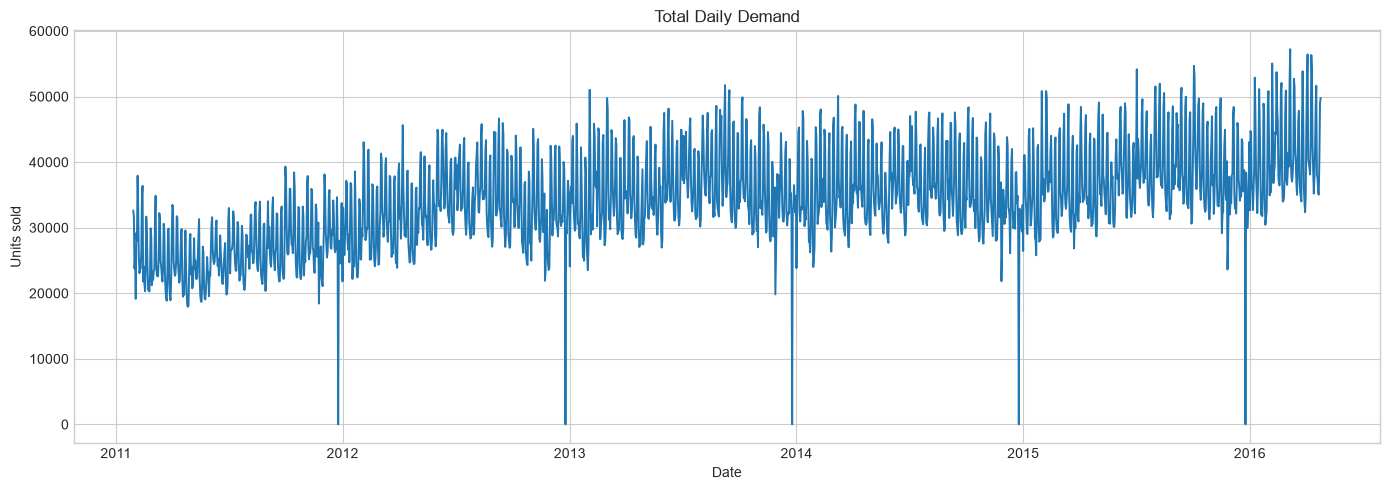

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total['date'], daily_total['demand'], linewidth=1.4, color='#1f77b4')
ax.set_title('Total Daily Demand')
ax.set_xlabel('Date')
ax.set_ylabel('Units sold')
plt.tight_layout()

## Demand By State

,total_demand
state_id,
CA,28675547
TX,18899006
WI,18120856


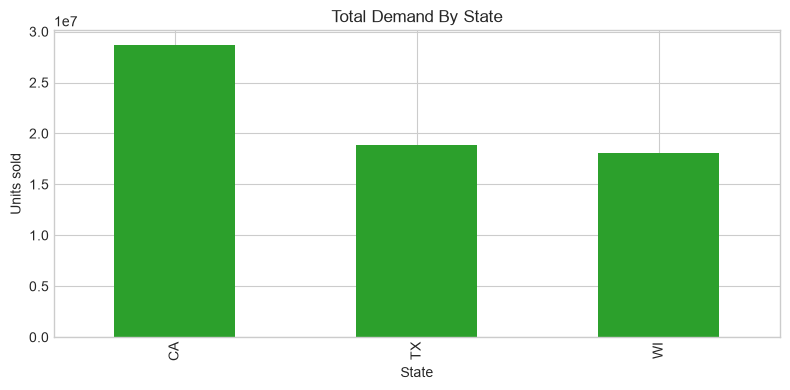

In [5]:
state_totals = daily_state.groupby('state_id')['demand'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
state_totals.plot(kind='bar', ax=ax, color='#2ca02c')
ax.set_title('Total Demand By State')
ax.set_xlabel('State')
ax.set_ylabel('Units sold')
plt.tight_layout()
state_totals.to_frame('total_demand')

## Demand By Store

,total_demand
store_id,
CA_3,11188180
CA_1,7698216
TX_2,7214384
WI_2,6544012
WI_3,6427782
TX_3,6089330
CA_2,5685475
TX_1,5595292
WI_1,5149062


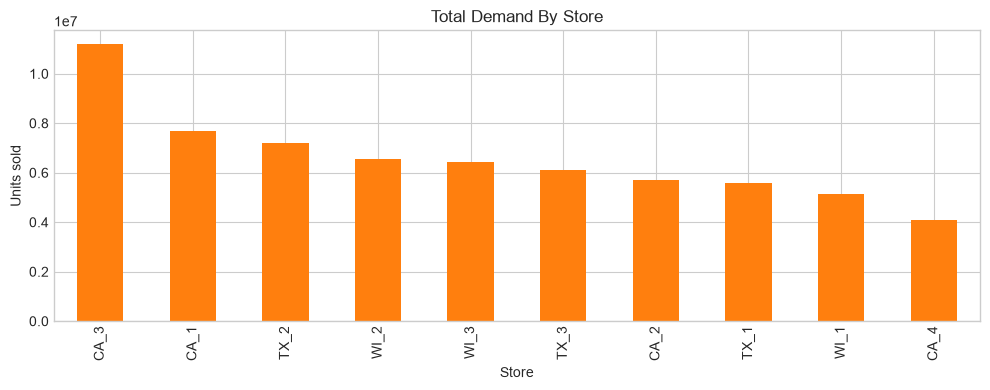

In [6]:
store_totals = daily_store.groupby('store_id')['demand'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
store_totals.plot(kind='bar', ax=ax, color='#ff7f0e')
ax.set_title('Total Demand By Store')
ax.set_xlabel('Store')
ax.set_ylabel('Units sold')
plt.tight_layout()
store_totals.to_frame('total_demand')

## Demand By Category

,total_demand
cat_id,
FOODS,45089939
HOUSEHOLD,14480670
HOBBIES,6124800


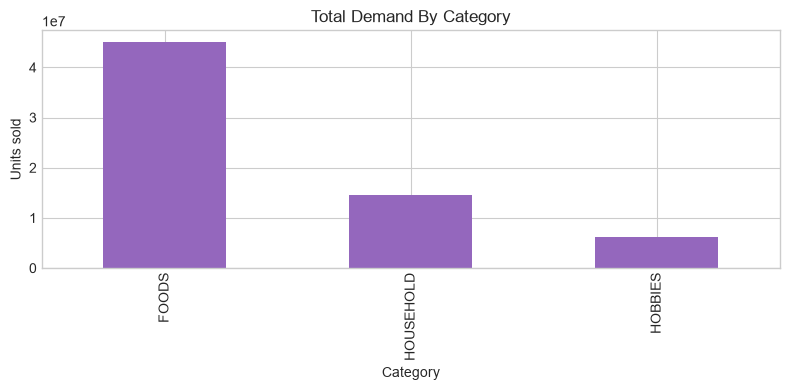

In [7]:
category_totals = daily_category.groupby('cat_id')['demand'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
category_totals.plot(kind='bar', ax=ax, color='#9467bd')
ax.set_title('Total Demand By Category')
ax.set_xlabel('Category')
ax.set_ylabel('Units sold')
plt.tight_layout()
category_totals.to_frame('total_demand')

## Top 20 Products By Demand

,item_id,dept_id,cat_id,total_demand,series_count
0,FOODS_3_090,FOODS_3,FOODS,1002529,10
1,FOODS_3_586,FOODS_3,FOODS,920242,10
2,FOODS_3_252,FOODS_3,FOODS,565299,10
3,FOODS_3_555,FOODS_3,FOODS,491287,10
4,FOODS_3_714,FOODS_3,FOODS,396172,10
5,FOODS_3_587,FOODS_3,FOODS,396119,10
6,FOODS_3_694,FOODS_3,FOODS,390001,10
7,FOODS_3_226,FOODS_3,FOODS,363082,10
8,FOODS_3_202,FOODS_3,FOODS,295689,10
9,FOODS_3_723,FOODS_3,FOODS,284333,10


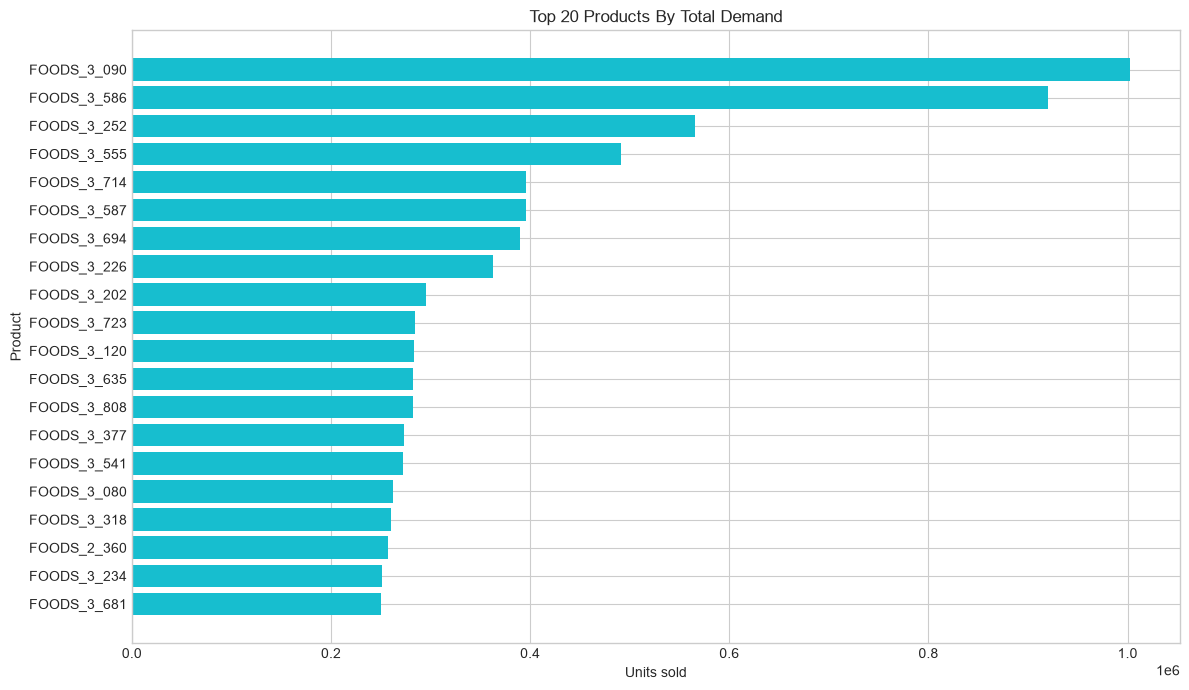

In [8]:
top20_products = product_summary.nlargest(20, 'total_demand')
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top20_products['item_id'][::-1], top20_products['total_demand'][::-1], color='#17becf')
ax.set_title('Top 20 Products By Total Demand')
ax.set_xlabel('Units sold')
ax.set_ylabel('Product')
plt.tight_layout()
top20_products[['item_id', 'dept_id', 'cat_id', 'total_demand', 'series_count']]

## Initial Takeaways

- The processed tables are intentionally aggregated to support fast iteration.
- Product-store level modeling will be handled in later phases after data cleaning and feature engineering.
- Intermittent demand and zero-heavy series should be treated carefully during baseline and ML model design.